Deep-Dive Analysis: Employee Burnout & Productivity

Objective
The goal of this project is to analyze workplace behavioral data to understand the key factors influencing employee burnout and productivity. 

We aim to:
- Define important business KPIs
- Analyze relationships between work patterns and burnout
- Identify key drivers of productivity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [3]:
df = pd.read_csv("cleaned_burnout_dataset.csv")
df.head()

,user_id,day_type,work_hours,screen_time_hours,meetings_count,breaks_taken,after_hours_work,sleep_hours,task_completion_rate,burnout_score,burnout_risk,productivity_index,work_intensity
0,1,Weekday,9.59,11.86,4,2,No,7.55,91.2,19.17,Low,9.509906,15.86
1,1,Weekend,7.38,10.33,4,1,No,6.69,82.0,29.70,Low,11.111111,14.33
2,1,Weekend,6.31,8.92,1,2,No,8.87,80.6,32.93,Low,12.773376,9.92
3,1,Weekday,8.34,10.70,4,1,Yes,8.13,70.0,45.47,Low,8.393285,14.70
4,1,Weekend,6.97,9.83,1,2,No,5.85,67.1,51.61,Low,9.626973,10.83


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_id               1800 non-null   int64  
 1   day_type              1800 non-null   object 
 2   work_hours            1800 non-null   float64
 3   screen_time_hours     1800 non-null   float64
 4   meetings_count        1800 non-null   int64  
 5   breaks_taken          1800 non-null   int64  
 6   after_hours_work      1800 non-null   object 
 7   sleep_hours           1800 non-null   float64
 8   task_completion_rate  1800 non-null   float64
 9   burnout_score         1800 non-null   float64
 10  burnout_risk          1800 non-null   object 
 11  productivity_index    1800 non-null   float64
 12  work_intensity        1800 non-null   float64
dtypes: float64(7), int64(3), object(3)
memory usage: 182.9+ KB


,user_id,work_hours,screen_time_hours,meetings_count,breaks_taken,sleep_hours,task_completion_rate,burnout_score,productivity_index,work_intensity
count,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000,1800.000000
mean,90.500000,6.515117,9.271406,1.941111,3.028889,6.996467,72.308556,44.009978,12.928351,11.212517
std,51.975162,2.290521,2.409253,1.696178,1.417844,1.061740,14.978647,23.881782,6.218871,3.561833
min,1.000000,3.000000,4.510000,0.000000,1.000000,4.500000,40.000000,2.500000,3.361345,4.510000
25%,45.750000,4.430000,7.240000,1.000000,2.000000,6.280000,62.300000,25.370000,8.220476,8.170000
50%,90.500000,6.445000,9.210000,2.000000,3.000000,6.990000,74.500000,39.270000,11.092421,10.730000
75%,135.250000,8.510000,11.310000,3.000000,4.000000,7.750000,83.700000,58.197500,16.436366,14.120000
max,180.000000,12.170000,15.700000,10.000000,5.000000,10.800000,107.200000,143.920000,35.033333,21.810000


Key Performance Indicators (KPIs)

KPIs help measure overall employee well-being and performance levels in the organization.

The following KPIs were selected:
1. Average Burnout Score
2. Average Productivity Index
3. Average Work Hours
4. Percentage of Employees Working After Hours
5. Average Sleep Hours

These metrics provide insight into workload, recovery, and performance trends.

In [5]:
avg_burnout = df['burnout_score'].mean()
print("Average Burnout Score:", round(avg_burnout, 2))

Average Burnout Score: 44.01


In [6]:
avg_productivity = df['productivity_index'].mean()
print("Average Productivity Index:", round(avg_productivity, 2))

Average Productivity Index: 12.93


In [7]:
avg_work_hours = df['work_hours'].mean()
print("Average Work Hours:", round(avg_work_hours, 2))

Average Work Hours: 6.52


In [8]:
after_hours_percent = (df['after_hours_work'] == 'Yes').mean() * 100
print("Percentage Working After Hours:", round(after_hours_percent, 2), "%")

Percentage Working After Hours: 35.89 %


In [9]:
avg_sleep = df['sleep_hours'].mean()
print("Average Sleep Hours:", round(avg_sleep, 2))

Average Sleep Hours: 7.0


Deep-Dive Analysis: Factors Affecting Burnout

To understand what influences burnout and productivity, we analyze relationships between:

- Work Hours
- Sleep Hours
- Burnout Score
- Productivity Index

Correlation analysis helps identify whether these variables move together positively or negatively.

In [10]:
correlation_data = df[['work_hours', 'sleep_hours', 
                       'burnout_score', 'productivity_index']]

corr_matrix = correlation_data.corr()

print(corr_matrix)

                    work_hours  sleep_hours  burnout_score  productivity_index
work_hours            1.000000     0.011896       0.119319           -0.837363
sleep_hours           0.011896     1.000000      -0.006151           -0.011933
burnout_score         0.119319    -0.006151       1.000000           -0.510290
productivity_index   -0.837363    -0.011933      -0.510290            1.000000


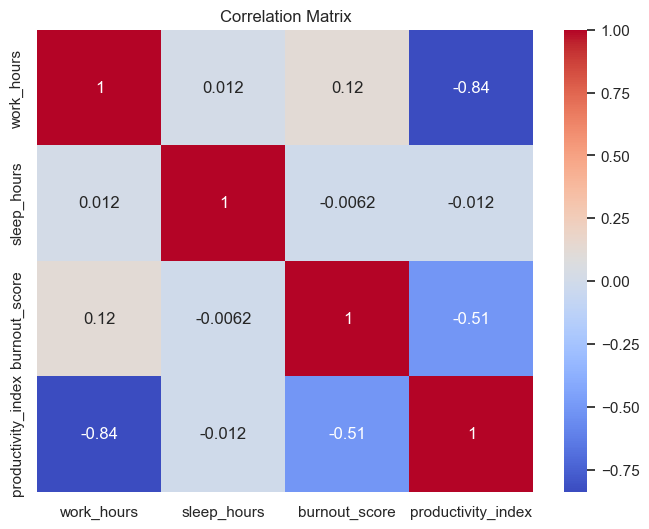

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Correlation Insights

- A positive correlation between work hours and burnout suggests longer working hours may increase stress levels.
- A negative correlation between sleep and burnout suggests better sleep may reduce burnout.
- Productivity shows relationship trends with both workload and rest patterns.

This indicates that work-life balance plays a significant role in employee well-being.

In [12]:
burnout_after_hours = df.groupby('after_hours_work')['burnout_score'].mean()
print(burnout_after_hours)

after_hours_work
No     43.689021
Yes    44.583328
Name: burnout_score, dtype: float64


In [13]:
productivity_after_hours = df.groupby('after_hours_work')['productivity_index'].mean()
print(productivity_after_hours)

after_hours_work
No     12.947360
Yes    12.894393
Name: productivity_index, dtype: float64


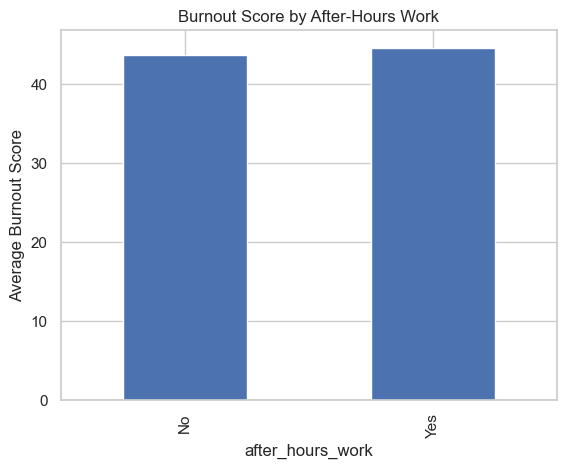

In [14]:
burnout_after_hours.plot(kind='bar')
plt.title("Burnout Score by After-Hours Work")
plt.ylabel("Average Burnout Score")
plt.show()

After-Hours Work Impact

Employees working after hours tend to show higher burnout levels compared to those who do not.

This suggests that extended work beyond regular hours may negatively impact employee mental well-being.

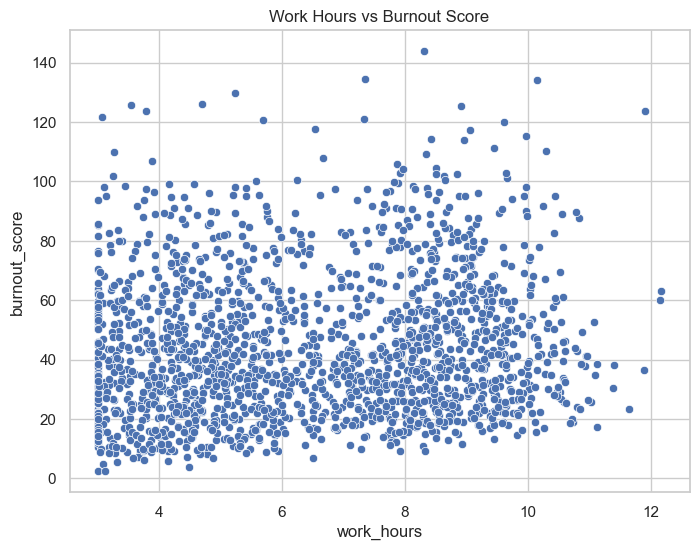

In [15]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='work_hours', y='burnout_score', data=df)
plt.title("Work Hours vs Burnout Score")
plt.show()

The scatter plot shows an upward trend, indicating that increased work hours are associated with higher burnout levels.

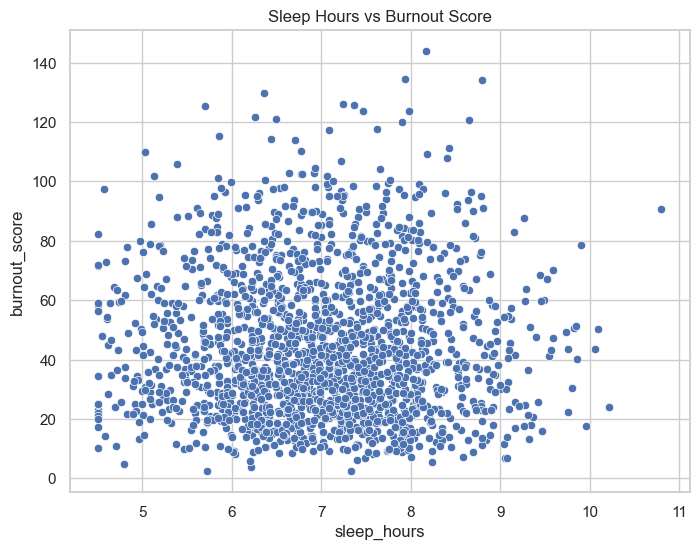

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='sleep_hours', y='burnout_score', data=df)
plt.title("Sleep Hours vs Burnout Score")
plt.show()

The scatter plot suggests that lower sleep hours are associated with higher burnout scores, reinforcing the importance of adequate rest.

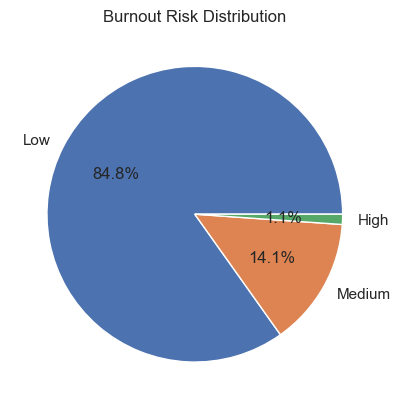

In [17]:
risk_counts = df['burnout_risk'].value_counts()

risk_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title("Burnout Risk Distribution")
plt.ylabel("")
plt.show()

In [18]:
day_burnout = df.groupby('day_type')['burnout_score'].mean()
print(day_burnout)

day_type
Weekday    46.824189
Weekend    41.341959
Name: burnout_score, dtype: float64


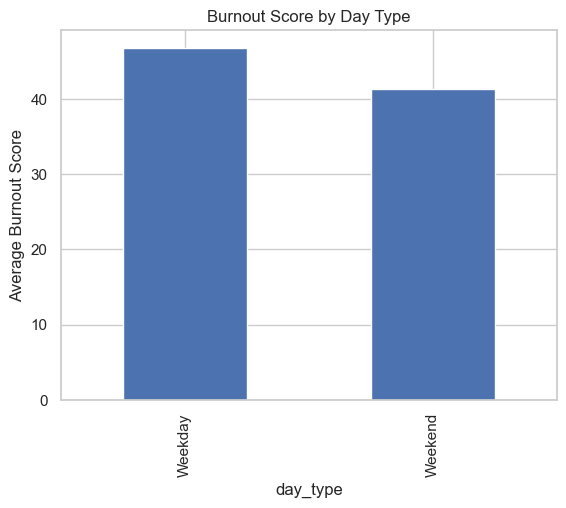

In [19]:
day_burnout.plot(kind='bar')
plt.title("Burnout Score by Day Type")
plt.ylabel("Average Burnout Score")
plt.show()

In [20]:
df.to_csv("burnout_dashboard_data.csv", index=False)

 Conclusion

The analysis suggests that:

- Longer work hours increase burnout risk.
- Lower sleep hours contribute to higher stress.
- After-hours work significantly impacts employee well-being.
- Burnout levels directly influence productivity performance.

Organizations should monitor workload distribution and encourage healthy work-life balance to improve long-term productivity and employee health.